<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/deep_learning/object_detection_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Object Detection with YOLO

So far every vision model predicted a fixed-size output per image: one class ([`notes_NN/03`](../notes_NN/03_cnn_transfer_multitask.ipynb)), or a class plus a few numbers such as eye coordinates (the face labs). **Object detection** asks for *every* object in the image, each with a box and a class, and the number of objects is not known in advance.

This notebook first builds the core ideas from scratch (box formats, IoU, dense prediction, non-maximum suppression, mAP), each checked against a library implementation. Then it fine-tunes a pretrained **YOLO11n** on a small wildlife dataset and wraps the trained model in a small web application.

> **Unlike the other notes, this one downloads data and weights.** It uses the *African Wildlife* dataset by Ultralytics (≈100 MB, 1,504 photos, 4 classes: buffalo, elephant, rhino, zebra, AGPL-3.0 licence) and the COCO-pretrained YOLO11n weights (≈5 MB). Training takes about 1 minute on a recent GPU, several minutes on a Colab T4, and ≈5–10 minutes on a laptop CPU, where the settings are reduced automatically (section 9). In Colab, use **Runtime → Change runtime type → T4 GPU**.

**Contents**

1. From classification to detection
2. The dataset and bounding-box formats
3. Intersection over Union (IoU)
4. Detection as dense prediction: how YOLO works
5. Training targets and the loss
6. Post-processing: confidence threshold and NMS
7. Evaluating a detector: precision, recall and mAP
8. Baseline: the COCO-pretrained model
9. Fine-tuning YOLO on the wildlife dataset
10. Evaluation on the test set (and our own mAP)
11. Looking at the predictions
12. Speed and export to ONNX
13. A small application
14. Going further

In [1]:
# Installs the two packages this notebook needs if they are missing (Colab ships neither).
import importlib.util, subprocess, sys
missing = [p for p in ("ultralytics", "gradio") if importlib.util.find_spec(p) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
IN_COLAB = "google.colab" in sys.modules

In [2]:
import io, time, urllib.request, zipfile
from pathlib import Path
from IPython.display import display, Image as ImageDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch, torchvision
import ultralytics
from ultralytics import YOLO

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0); torch.manual_seed(0)
DEVICE = 0 if torch.cuda.is_available() else "cpu"

def show_photos(fig):
    # figures of photographs are ~10x smaller as JPEG than as PNG, which keeps the saved notebook light
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", dpi=90, bbox_inches="tight", pil_kwargs={"quality": 85}); plt.close(fig)
    display(ImageDisplay(buf.getvalue()))

print(f"ultralytics {ultralytics.__version__}, torch {torch.__version__}, device:",
      torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU")

ultralytics 8.4.52, torch 2.12.0+cu130, device: NVIDIA GeForce RTX 5090


## 1. From classification to detection

| Task | Output per image | Example |
|---|---|---|
| **Classification** | one label | "zebra" |
| **Classification + localisation** | one label and one box (4 numbers, a regression) | "zebra at $(x_1,y_1,x_2,y_2)$"; the eye coordinates of the face labs |
| **Object detection** | a **set** of $(\text{box}, \text{class}, \text{score})$ triples, of unknown size | 3 zebras and 1 elephant, each with its box |
| **Instance segmentation** | a set of (pixel mask, class, score) | the exact outline of each zebra |

Detection cannot be treated as a plain regression with a fixed output vector:

- **Unknown number of objects.** An image may contain 0, 1 or 30 objects.
- **The output is a set.** The order of the objects is meaningless, so "the first box" is not defined, and neither is a loss that compares output $k$ with target $k$.
- **Scale varies wildly.** The same class can cover 20 pixels or the whole image.
- **Extreme imbalance.** Most of the image is background.

Two families of detectors handle this:

- **Two-stage** (R-CNN, Fast/Faster R-CNN): first propose a few thousand candidate regions, then classify each one and refine its box. Accurate, but slower.
- **One-stage** (YOLO, SSD, RetinaNet): a single CNN pass predicts a box and class scores **at every location of a grid**. Overlapping duplicates are then removed. YOLO ("*You Only Look Once*", Redmon et al., 2016) started this family and, through many versions, is the standard choice for real-time detection. We use YOLO11 from the `ultralytics` package.

## 2. The dataset and bounding-box formats

The dataset is downloaded once into `data/` (git-ignored). Ultralytics uses a simple folder layout:

```
african-wildlife/
├── images/{train,val,test}/xxx.jpg
└── labels/{train,val,test}/xxx.txt     ← one text file per image, same name
```

We also write a small `data.yaml` that tells YOLO where the splits are and what the class names are. It uses an absolute path, because Ultralytics resolves a relative `path:` against its own global datasets folder rather than the current directory.

In [3]:
DATA_ROOT = Path("data/african-wildlife")
URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip"
if not (DATA_ROOT / "images").exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_ROOT.parent / "african-wildlife.zip"
    print("downloading", URL); urllib.request.urlretrieve(URL, zip_path)
    zipfile.ZipFile(zip_path).extractall(DATA_ROOT); zip_path.unlink()

CLASSES = ["buffalo", "elephant", "rhino", "zebra"]
COLORS = ["#8c564b", "#1f77b4", "#7f7f7f", "#d62728"]
DATA_YAML = DATA_ROOT / "data.yaml"
DATA_YAML.write_text(f"path: {DATA_ROOT.resolve()}\ntrain: images/train\nval: images/val\ntest: images/test\n"
                     "names:\n" + "".join(f"  {i}: {c}\n" for i, c in enumerate(CLASSES)))

def images(split):
    return sorted(p for p in (DATA_ROOT / "images" / split).iterdir() if p.suffix.lower() == ".jpg")

def read_labels(img_path):
    # YOLO label file -> class ids (k,) and boxes (k, 4) as normalised (x_centre, y_centre, w, h)
    lbl = DATA_ROOT / "labels" / Path(img_path).parent.name / f"{Path(img_path).stem}.txt"
    a = np.loadtxt(lbl, ndmin=2) if lbl.exists() and lbl.stat().st_size else np.zeros((0, 5))
    return a[:, 0].astype(int), a[:, 1:]

def load(img_path):
    return np.asarray(Image.open(img_path).convert("RGB"))

p = images("train")[0]
print(f"{p.name}: {load(p).shape}, label file:")
print((DATA_ROOT / "labels/train" / f"{p.stem}.txt").read_text())

1 (10).jpg: (400, 300, 3), label file:
0 0.410000 0.408750 0.400000 0.382500


Each line of a label file is `class x_centre y_centre width height`, with the four coordinates **divided by the image width and height**, so they lie in $[0,1]$. Normalised labels survive any resizing of the image unchanged. Three box formats are in common use:

| Format | Numbers | Used by |
|---|---|---|
| `xyxy` | corners $(x_1, y_1, x_2, y_2)$ in pixels | IoU, NMS, drawing, `torchvision` |
| `xywh` | centre $(x_c, y_c)$, width, height in pixels | YOLO's internal box prediction |
| `xywhn` | `xywh` divided by $(W, H, W, H)$ | YOLO label files |

The conversion is $x_1 = (x_c - w/2)\,W$, $x_2 = (x_c + w/2)\,W$, and the same for $y$ with $H$. Image coordinates have the origin at the **top-left** corner and $y$ pointing **down**.

In [4]:
def xywhn_to_xyxy(b, W, H):
    xc, yc, w, h = np.asarray(b, float).reshape(-1, 4).T
    return np.stack([(xc - w / 2) * W, (yc - h / 2) * H, (xc + w / 2) * W, (yc + h / 2) * H], axis=1)

def xyxy_to_xywhn(b, W, H):
    x1, y1, x2, y2 = np.asarray(b, float).reshape(-1, 4).T
    return np.stack([(x1 + x2) / 2 / W, (y1 + y2) / 2 / H, (x2 - x1) / W, (y2 - y1) / H], axis=1)

cls, xywhn = read_labels(p); H, W = load(p).shape[:2]
xyxy = xywhn_to_xyxy(xywhn, W, H)
print("xyxy (pixels):\n", xyxy.round(1))
print("round trip error:", np.abs(xyxy_to_xywhn(xyxy, W, H) - xywhn).max())

xyxy (pixels):
 [[         63          87         183         240]]
round trip error: 0.0


A quick look at the data: how many objects of each class, how many objects per image, and how large they are. The box sizes matter: a detector must handle objects from a few percent of the image up to the whole frame.

cls    buffalo  elephant  rhino  zebra  images  objects/image
split                                                        
train      399       558    399    575    1052           1.84
val         89        91     85    114     225           1.68
test        66        99     75    135     227           1.65 



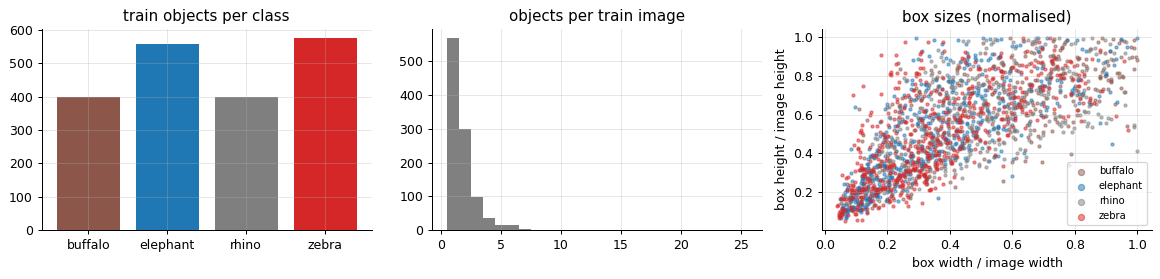

In [5]:
rows = []
for split in ("train", "val", "test"):
    for p in images(split):
        for c, (xc, yc, w, h) in zip(*read_labels(p)):
            rows.append(dict(split=split, image=p.name, cls=CLASSES[c], w=w, h=h))
boxes_df = pd.DataFrame(rows)
summary = boxes_df.pivot_table(index="split", columns="cls", values="w", aggfunc="count")
summary["images"] = [len(images(s)) for s in summary.index]
summary["objects/image"] = (summary[CLASSES].sum(axis=1) / summary["images"]).round(2)
print(summary.loc[["train", "val", "test"]], "\n")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
per_img = boxes_df[boxes_df.split == "train"].groupby("image").size()
axes[0].bar(CLASSES, summary.loc["train", CLASSES], color=COLORS); axes[0].set_title("train objects per class")
axes[1].hist(per_img, bins=np.arange(0.5, per_img.max() + 1.5), color="gray"); axes[1].set_title("objects per train image")
for c, col in zip(CLASSES, COLORS):
    d = boxes_df[(boxes_df.split == "train") & (boxes_df.cls == c)]
    axes[2].scatter(d.w, d.h, s=6, alpha=0.5, color=col, label=c)
axes[2].set_xlabel("box width / image width"); axes[2].set_ylabel("box height / image height")
axes[2].set_title("box sizes (normalised)"); axes[2].legend(fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()

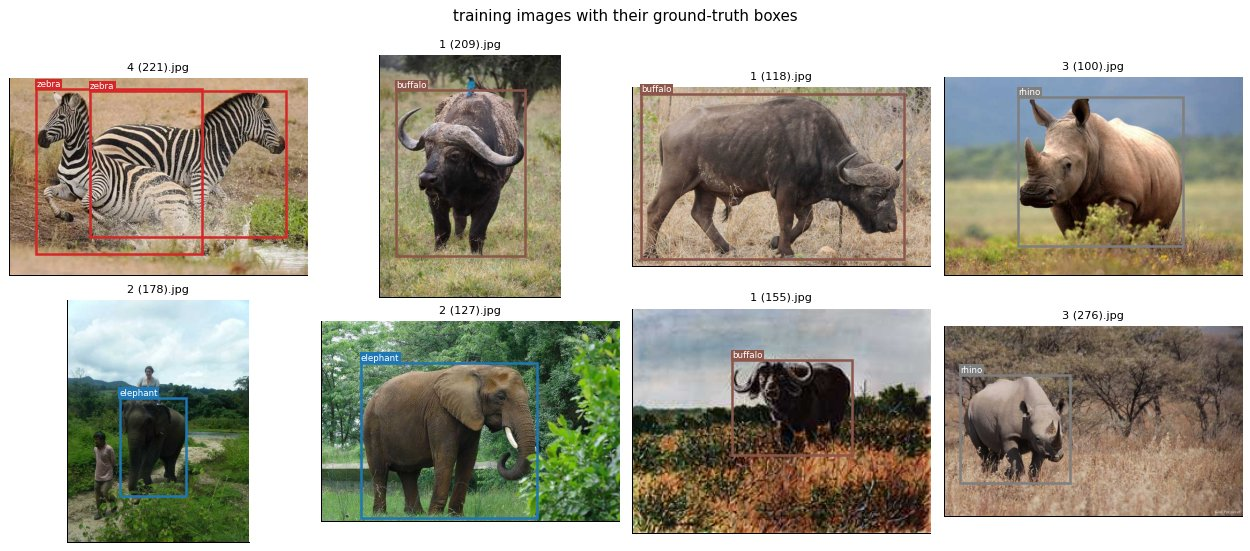

In [6]:
def draw(ax, img, boxes, labels, colors, dashed=False, title=None):
    # draws xyxy boxes with a text label on top of each one
    ax.imshow(img); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for (x1, y1, x2, y2), text, col in zip(boxes, labels, colors):
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2, ec=col, ls="--" if dashed else "-"))
        if text:
            ax.text(x1, y1, text, color="white", fontsize=7, va="bottom", bbox=dict(fc=col, ec="none", pad=1))
    if title: ax.set_title(title, fontsize=9)

def draw_gt(ax, p, dashed=False, title=None, show_text=True):
    img = load(p); cls, xywhn = read_labels(p)
    draw(ax, img, xywhn_to_xyxy(xywhn, img.shape[1], img.shape[0]),
         [CLASSES[c] if show_text else "" for c in cls], [COLORS[c] for c in cls], dashed, title)

fig, axes = plt.subplots(2, 4, figsize=(14, 6.2))
for ax, p in zip(axes.ravel(), rng.choice(images("train"), 8, replace=False)):
    draw_gt(ax, p, title=p.name)
plt.suptitle("training images with their ground-truth boxes"); plt.tight_layout(); show_photos(fig)

**Real datasets contain label errors.** The file names keep the photo's source folder (`1` buffalo, `2` elephant, `3` rhino, `4` zebra). Many images whose labels disagree with the folder are genuine mixed scenes (a zebra behind an elephant), but some are plain mistakes, like the rhinos and zebras below. A detector is trained to reproduce these labels and is scored against them, so a few "errors" on the test set may be errors of the annotation instead. Checking images where the labels disagree with some independent signal (here the folder, in general the model's own confident predictions) is a cheap way to find them.

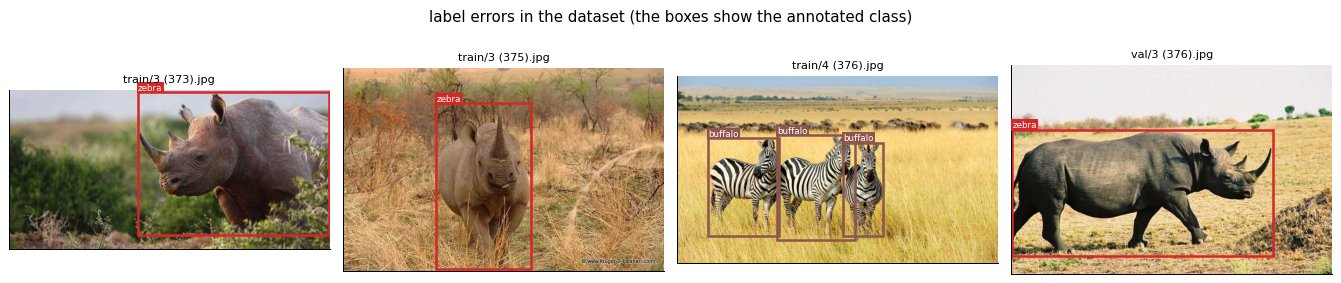

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, name in zip(axes, ["3 (373).jpg", "3 (375).jpg", "4 (376).jpg", "3 (376).jpg"]):
    p = next(p for s in ("train", "val") for p in images(s) if p.name == name)
    draw_gt(ax, p, title=f"{p.parent.name}/{name}")
plt.suptitle("label errors in the dataset (the boxes show the annotated class)"); plt.tight_layout(); show_photos(fig)

## 3. Intersection over Union (IoU)

To say whether a predicted box is "right" we need a similarity between two boxes. The standard one is the **Intersection over Union**:

$$
\text{IoU}(A, B) = \frac{|A\cap B|}{|A\cup B|} = \frac{|A\cap B|}{|A| + |B| - |A\cap B|} \in [0, 1].
$$

**Computing the intersection.** Two intervals $[a_1, a_2]$ and $[b_1, b_2]$ intersect in $[\max(a_1,b_1), \min(a_2,b_2)]$, which is empty when $\max(a_1,b_1) > \min(a_2,b_2)$. An axis-aligned rectangle is the product of an $x$-interval and a $y$-interval, and so is the intersection of two such rectangles. Hence

$$
|A\cap B| = \big[\min(x_2^A, x_2^B) - \max(x_1^A, x_1^B)\big]_+ \cdot \big[\min(y_2^A, y_2^B) - \max(y_1^A, y_1^B)\big]_+ ,\qquad [t]_+ = \max(t, 0).
$$

**Properties.**
- $\text{IoU} = 1$ iff the boxes are identical, and $0$ iff they don't overlap.
- **Scale invariance.** Scaling both boxes by a factor $s$ multiplies every area by $s^2$, so the ratio is unchanged. An error of 10 pixels is serious for a 30-pixel box but negligible for a 600-pixel one, and IoU reflects that. A squared error on the coordinates does not: it would be dominated by the large objects.

**How strict is IoU = 0.5?** Take a square of side $L$ and shift a copy horizontally by $d \le L$. The intersection is $L(L-d)$ and the union is $2L^2 - L(L-d) = L(L+d)$, so
$$
\text{IoU} = \frac{L-d}{L+d}, \qquad \text{IoU} = 0.5 \iff d = L/3 .
$$
Enlarging a box by a factor $k$ around the same centre gives $\text{IoU} = 1/k^2$, which equals $0.5$ at $k=\sqrt 2$: every side 41% too long. So IoU $\ge 0.5$, the classic threshold for a correct detection, is a fairly loose requirement. That is why COCO also averages over stricter thresholds up to 0.95 (section 7).

**IoU as a loss, and its fix.** $1 - \text{IoU}$ is a natural box loss, but it is constant ($=1$) whenever the boxes don't overlap, so it gives no gradient telling a far-away prediction which way to move. **GIoU** (Rezatofighi et al., 2019) subtracts the fraction of the smallest enclosing box $C$ not covered by the union:
$$
\text{GIoU} = \text{IoU} - \frac{|C \setminus (A\cup B)|}{|C|} \in (-1, 1],
$$
which keeps decreasing as the boxes move apart. YOLO uses **CIoU**, which instead penalises the distance between the centres $\rho$ (relative to the diagonal $c$ of $C$) and the difference in aspect ratio:
$\text{CIoU} = \text{IoU} - \rho^2/c^2 - \alpha v$, with $v = \tfrac{4}{\pi^2}\big(\arctan\tfrac{w^{gt}}{h^{gt}} - \arctan\tfrac{w}{h}\big)^2$. The box loss is $1 - \text{CIoU}$.

In [8]:
def area(X):
    return (X[:, 2] - X[:, 0]) * (X[:, 3] - X[:, 1])

def box_iou(A, B):
    # pairwise IoU between A (n, 4) and B (m, 4), xyxy format -> (n, m)
    A, B = np.asarray(A, float).reshape(-1, 4), np.asarray(B, float).reshape(-1, 4)
    iw = np.clip(np.minimum(A[:, None, 2], B[None, :, 2]) - np.maximum(A[:, None, 0], B[None, :, 0]), 0, None)
    ih = np.clip(np.minimum(A[:, None, 3], B[None, :, 3]) - np.maximum(A[:, None, 1], B[None, :, 1]), 0, None)
    inter = iw * ih
    return inter / (area(A)[:, None] + area(B)[None, :] - inter)

def box_giou(A, B):
    A, B = np.asarray(A, float).reshape(-1, 4), np.asarray(B, float).reshape(-1, 4)
    iou = box_iou(A, B)
    inter = iou * (area(A)[:, None] + area(B)[None, :]) / (1 + iou)          # from IoU = I / (|A| + |B| - I)
    union = area(A)[:, None] + area(B)[None, :] - inter
    cw = np.maximum(A[:, None, 2], B[None, :, 2]) - np.minimum(A[:, None, 0], B[None, :, 0])
    ch = np.maximum(A[:, None, 3], B[None, :, 3]) - np.minimum(A[:, None, 1], B[None, :, 1])
    return iou - (cw * ch - union) / (cw * ch)

def random_boxes(n, size=500):
    xy = rng.uniform(0, size, (n, 2)); wh = rng.uniform(10, 200, (n, 2))
    return np.concatenate([xy, xy + wh], axis=1)

A, B = random_boxes(50), random_boxes(40)
print("max |ours - torchvision| IoU :", np.abs(box_iou(A, B) - torchvision.ops.box_iou(torch.tensor(A), torch.tensor(B)).numpy()).max())
print("max |ours - torchvision| GIoU:", np.abs(box_giou(A, B) - torchvision.ops.generalized_box_iou(torch.tensor(A), torch.tensor(B)).numpy()).max())
print("scale invariance, max |IoU(3A, 3B) - IoU(A, B)|:", np.abs(box_iou(3 * A, 3 * B) - box_iou(A, B)).max())

max |ours - torchvision| IoU : 0.0
max |ours - torchvision| GIoU: 1.942890293094024e-16
scale invariance, max |IoU(3A, 3B) - IoU(A, B)|: 8.326672684688674e-16


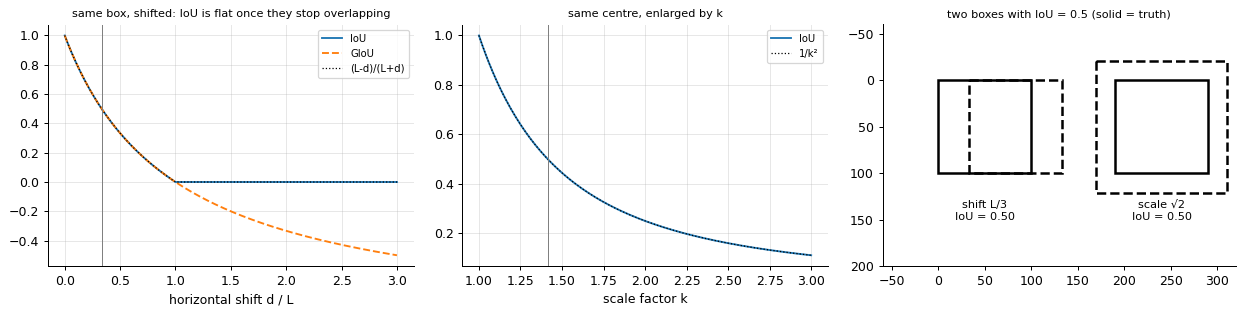

In [9]:
L = 100.0; sq = np.array([[0, 0, L, L]])
d = np.linspace(0, 3 * L, 301); shifted = np.stack([d, 0 * d, d + L, 0 * d + L], axis=1)
k = np.linspace(1, 3, 201); scaled = np.stack([L / 2 - k * L / 2, L / 2 - k * L / 2, L / 2 + k * L / 2, L / 2 + k * L / 2], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].plot(d / L, box_iou(sq, shifted)[0], label="IoU"); axes[0].plot(d / L, box_giou(sq, shifted)[0], "--", label="GIoU")
axes[0].plot(d / L, (L - np.minimum(d, L)) / (L + np.minimum(d, L)), ":", c="k", lw=1, label="(L-d)/(L+d)")
axes[0].axvline(1 / 3, c="gray", lw=0.8); axes[0].set_xlabel("horizontal shift d / L"); axes[0].legend(fontsize=8)
axes[0].set_title("same box, shifted: IoU is flat once they stop overlapping", fontsize=9)
axes[1].plot(k, box_iou(sq, scaled)[0], label="IoU"); axes[1].plot(k, 1 / k**2, ":", c="k", lw=1, label="1/k²")
axes[1].axvline(np.sqrt(2), c="gray", lw=0.8); axes[1].set_xlabel("scale factor k"); axes[1].legend(fontsize=8)
axes[1].set_title("same centre, enlarged by k", fontsize=9)
ax = axes[2]; ax.set_aspect("equal"); ax.set_xlim(-60, 320); ax.set_ylim(-60, 200); ax.grid(False)
for (x0, gt, pr, t) in [(0, [0, 0, 100, 100], [100 / 3, 0, 100 + 100 / 3, 100], "shift L/3"),
                        (190, [190, 0, 290, 100], [190 - 20.7, -20.7, 290 + 20.7, 120.7], "scale √2")]:
    for b, ls in ((gt, "-"), (pr, "--")):
        ax.add_patch(mpatches.Rectangle(b[:2], b[2] - b[0], b[3] - b[1], fill=False, lw=2, ls=ls))
    ax.text(x0 + 50, 150, f"{t}\nIoU = {box_iou([gt], [pr])[0, 0]:.2f}", ha="center", fontsize=9)
ax.set_title("two boxes with IoU = 0.5 (solid = truth)", fontsize=9); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 4. Detection as dense prediction: how YOLO works

A YOLO network has three parts:

1. **Backbone**: a CNN ([`notes_NN/03`](../notes_NN/03_cnn_transfer_multitask.ipynb)) that turns the image into feature maps at decreasing resolutions.
2. **Neck** (FPN/PAN): combines those maps top-down and bottom-up, so that the fine, high-resolution maps also carry the semantics of the deep ones.
3. **Head**: at three scales, with **strides** $s = 8, 16, 32$, it predicts at *every* grid cell a box and a score for each class.

For a $640\times640$ input the three grids are $80\times80$, $40\times40$ and $20\times20$, i.e. $6400 + 1600 + 400 = 8400$ candidate detections per image, whatever the image contains. Each cell's receptive field (notebook 03, section 7) grows with the stride: the stride-8 grid detects small objects, and the stride-32 grid, whose cells see most of the image, detects large ones.

**Box parametrisation (anchor-free, YOLOv8 and later).** A cell $(i, j)$ of stride $s$ has centre $\big((j+\tfrac12)s, (i+\tfrac12)s\big) = (c_x, c_y)$. It predicts four non-negative distances $(l, t, r, b)$, in units of $s$, from that centre to the sides of the box:
$$
x_1 = c_x - l\,s,\quad y_1 = c_y - t\,s,\quad x_2 = c_x + r\,s,\quad y_2 = c_y + b\,s .
$$
Each distance is predicted not as one number but as a **distribution over 16 bins** $\{0, 1, \dots, 15\}$ (a softmax), and the distance is its expected value $\sum_k k\,p_k$. This is the *Distribution Focal Loss* (DFL) head. It lets the network express uncertainty about a blurry edge, and it caps the distance at $15s$: at most 120 pixels from the centre at stride 8, but 480 pixels at stride 32.

**Class scores** are independent sigmoids, not a softmax: a cell may say "nothing" (all scores low), and the loss is a binary cross-entropy per class. The detection confidence is the highest class score.

So the head outputs $4\times16 + n_c$ numbers per cell (144 for COCO's 80 classes), and after decoding the box distributions, $4 + n_c$. We can check this on the COCO-pretrained model: its raw output is a tensor $(1,\, 4 + 80,\, 8400)$.

In [10]:
coco = YOLO("yolo11n.pt")          # COCO-pretrained, downloads 5 MB on first use
net = coco.model.eval()
head = net.model[-1]
print(f"YOLO11n: {sum(p.numel() for p in net.parameters()) / 1e6:.2f} M parameters, "
      f"strides {net.stride.int().tolist()}, head: {head.nc} classes, {head.reg_max} bins per distance, "
      f"{head.no} = 4*{head.reg_max} + {head.nc} channels per cell")
for s in (640, 320):
    with torch.no_grad():
        raw = net(torch.zeros(1, 3, s, s))[0]
    grids = [s // int(st) for st in net.stride]
    print(f"input {s}x{s}: raw output {tuple(raw.shape)};  cells {' + '.join(f'{g}²' for g in grids)} = {sum(g * g for g in grids)}")

YOLO11n: 2.62 M parameters, strides [8, 16, 32], head: 80 classes, 16 bins per distance, 144 = 4*16 + 80 channels per cell
input 640x640: raw output (1, 84, 8400);  cells 80² + 40² + 20² = 8400
input 320x320: raw output (1, 84, 2100);  cells 40² + 20² + 10² = 2100


## 5. Training targets and the loss

With 8400 predictions and a handful of ground-truth boxes, training first has to decide **which predictions are responsible for which object** (the *assignment*). Everything not assigned is a negative: its class scores are pushed to 0.

YOLOv8/11 use the **Task-Aligned Assigner** (TOOD, Feng et al., 2021). For each ground-truth box $g$ of class $c$:
1. The candidates are the cells whose centre lies inside $g$.
2. Each candidate gets an alignment score $t = \hat{s}_c^{\,\alpha}\cdot \text{IoU}(\hat{b}, g)^{\beta}$, with $\hat{s}_c$ its current score for class $c$ and $\hat b$ its current box ($\alpha = 0.5$, $\beta = 6$ in Ultralytics).
3. The top $k=10$ candidates are positives for $g$.

The assignment thus depends on the network's *current* predictions: it rewards cells that are both confident and well localised, and it changes during training.

The loss has three terms, which are the three columns printed during training:
$$
J = \lambda_{\text{box}}\,\underbrace{\big(1 - \text{CIoU}\big)}_{\texttt{box\_loss}} \;+\; \lambda_{\text{cls}}\,\underbrace{\text{BCE}(\hat{\mathbf{s}}, \mathbf{t})}_{\texttt{cls\_loss}} \;+\; \lambda_{\text{dfl}}\,\underbrace{\text{DFL}}_{\texttt{dfl\_loss}}, \qquad
\lambda_{\text{box}} = 7.5,\;\lambda_{\text{cls}} = 0.5,\;\lambda_{\text{dfl}} = 1.5 .
$$
- The box and DFL terms are computed on the positives only.
- The classification BCE runs over **all** 8400 cells and all classes. The target of a positive is not 1 but its (normalised) alignment score, so the predicted class score learns to also reflect how good the box is. That is what makes it usable as a ranking score in NMS and mAP.
- **DFL.** If the target distance $y$ lies between bins $k$ and $k+1$, the loss is a cross-entropy towards those two bins with weights $(k+1-y)$ and $(y-k)$: $\text{DFL} = -\big[(k+1-y)\log p_k + (y-k)\log p_{k+1}\big]$. The target distribution has expected value $k(k+1-y) + (k+1)(y-k) = y$, so it is the two-bin distribution that encodes $y$ exactly.

This is the same recipe as in the face labs (a weighted sum of a regression loss and a classification loss on a shared backbone), with the assignment step added in front.

In [11]:
y = 3.7; k = int(np.floor(y))
target = np.zeros(16); target[k], target[k + 1] = k + 1 - y, y - k
print(f"DFL target for distance {y}: bins {k}, {k + 1} with weights {target[k]:.1f}, {target[k + 1]:.1f};"
      f" expected value {(np.arange(16) * target).sum():.2f}")

n_obj = summary.loc["train", CLASSES].sum() / summary.loc["train", "images"]
print(f"imbalance: {n_obj:.2f} objects/image x 10 positives = {10 * n_obj:.0f} positive cells out of 8400"
      f" ({100 * 10 * n_obj / 8400:.2f}%)")

DFL target for distance 3.7: bins 3, 4 with weights 0.3, 0.7; expected value 3.70
imbalance: 1.84 objects/image x 10 positives = 18 positive cells out of 8400 (0.22%)


## 6. Post-processing: confidence threshold and NMS

A dense predictor fires many times on the same object: every cell near its centre, at more than one scale, predicts a slightly different box. Two steps turn 8400 candidates into a clean list:

1. **Confidence threshold**: discard candidates whose best class score is below `conf` (0.25 by default for prediction).
2. **Non-maximum suppression (NMS)**, for each class separately:
   - sort the remaining boxes by score;
   - keep the best one, and delete every other box whose IoU with it is above `iou` (0.7 in Ultralytics);
   - repeat with the next surviving box.

A standard trick for "separately for each class" is to shift the boxes of class $c$ by $c\cdot M$ along both axes, with $M$ larger than any coordinate: boxes of different classes then never overlap, and one NMS call does all classes at once (`torchvision.ops.batched_nms`).

The IoU threshold is a trade-off: too low and two genuinely overlapping animals get merged into one detection; too high and duplicates survive.

In [12]:
def nms(boxes, scores, iou_thr=0.7):
    # greedy NMS; returns the indices of the kept boxes, best first
    order, keep = np.argsort(-scores), []
    while order.size:
        i, rest = order[0], order[1:]
        keep.append(i)
        order = rest[box_iou(boxes[i], boxes[rest])[0] <= iou_thr]
    return np.array(keep, dtype=int)

def batched_nms(boxes, scores, classes, iou_thr=0.7):
    offset = classes[:, None] * (boxes.max() + 1)
    return nms(boxes + offset, scores, iou_thr)

B, S = random_boxes(500), rng.uniform(size=500)
ours, tv = nms(B, S, 0.5), torchvision.ops.nms(torch.tensor(B), torch.tensor(S), 0.5).numpy()
print(f"500 random boxes: we keep {len(ours)}, torchvision keeps {len(tv)}, identical: {np.array_equal(ours, tv)}")

500 random boxes: we keep 391, torchvision keeps 391, identical: True


Now on a real image and the raw output of the COCO model (84 × 8400). For simplicity we stretch the image to 640 × 640 instead of the *letterbox* resizing (keep the aspect ratio, pad with grey) that Ultralytics uses, so the boxes can differ slightly from `coco.predict`.

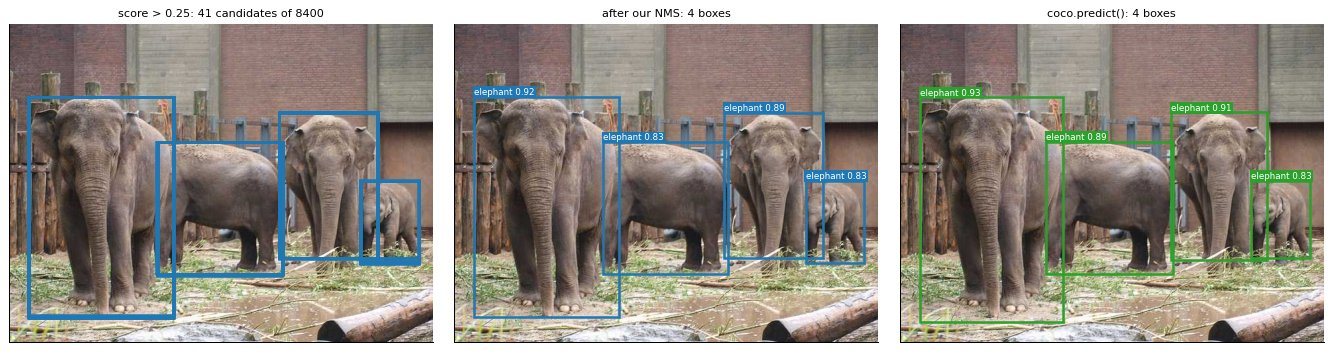

In [13]:
def raw_detections(net, img, size=640, conf=0.25):
    # runs the network on a stretched image; returns candidate boxes (in original pixels), scores, classes
    H, W = img.shape[:2]
    x = torch.from_numpy(np.array(Image.fromarray(img).resize((size, size)))).permute(2, 0, 1)[None].float() / 255
    with torch.no_grad():
        raw = net(x)[0][0].numpy()                     # (4 + nc, 8400): xywh in pixels, then class probabilities
    xywh, probs = raw[:4].T, raw[4:].T
    cls, score = probs.argmax(1), probs.max(1)
    xyxy = np.concatenate([xywh[:, :2] - xywh[:, 2:] / 2, xywh[:, :2] + xywh[:, 2:] / 2], axis=1)
    xyxy *= np.array([W / size, H / size, W / size, H / size])
    m = score > conf
    return xyxy[m], score[m], cls[m]

p = next(p for p in images("val") if (read_labels(p)[0] == 1).sum() >= 3)     # an image with several elephants
img = load(p)
boxes, scores, classes = raw_detections(net, img)
keep = batched_nms(boxes, scores, classes, 0.7)
res = coco.predict(np.ascontiguousarray(img[:, :, ::-1]), verbose=False)[0].cpu()        # Ultralytics expects BGR numpy arrays (OpenCV convention)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
draw(axes[0], img, boxes, [""] * len(boxes), ["#1f77b4"] * len(boxes), title=f"score > 0.25: {len(boxes)} candidates of 8400")
draw(axes[1], img, boxes[keep], [f"{coco.names[c]} {s:.2f}" for c, s in zip(classes[keep], scores[keep])],
     ["#1f77b4"] * len(keep), title=f"after our NMS: {len(keep)} boxes")
draw(axes[2], img, res.boxes.xyxy.numpy(), [f"{coco.names[int(c)]} {s:.2f}" for c, s in zip(res.boxes.cls, res.boxes.conf)],
     ["#2ca02c"] * len(res.boxes), title=f"coco.predict(): {len(res.boxes)} boxes")
plt.tight_layout(); show_photos(fig)

**NMS-free detectors.** NMS is a hand-written, non-differentiable step. It needs tuning, and its cost grows with the number of candidates. DETR (Carion et al., 2020) and, more recently, YOLOv10 and YOLO26 are trained with a **one-to-one assignment**: each object is matched to exactly one prediction (a Hungarian matching of the set of predictions to the set of targets), so duplicates are penalised during training and the raw output can be used directly. We stay with YOLO11 because its pipeline shows every step explicitly.

## 7. Evaluating a detector: precision, recall and mAP

**Matching.** For one class, sort all predictions on the dataset by score. A prediction is a **true positive** if its IoU with a not-yet-matched ground-truth box of the same class, in the same image, is at least a threshold (say 0.5). Otherwise it is a **false positive** (a wrong class, a duplicate, a bad box, or background). Ground-truth boxes left unmatched are **false negatives**.

**Precision–recall curve.** Keep only the top $k$ predictions, i.e. put the confidence threshold just below the $k$-th score. With $TP_k$ true positives among them and $N_{gt}$ ground-truth objects,
$$
P_k = \frac{TP_k}{k}, \qquad R_k = \frac{TP_k}{N_{gt}} .
$$
Lowering the threshold ($k \uparrow$) can only increase recall, while precision usually falls: the same trade-off as the ROC curve for classifiers, but with no true negatives. There is no meaningful count of "background boxes correctly not predicted".

**Average precision (AP)** is the area under the PR curve, after replacing precision by its **monotone envelope** $p_{\text{interp}}(r) = \max_{r' \ge r} p(r')$, since one could always choose the threshold that achieves the better precision at a higher recall. COCO samples this envelope at 101 recall values $0, 0.01, \dots, 1$ and averages.

- **mAP@0.5** (`mAP50`): the mean of AP over the classes at IoU threshold 0.5 (the PASCAL VOC metric).
- **mAP@0.5:0.95** (`mAP50-95`, the COCO metric): the mean over the thresholds $0.50, 0.55, \dots, 0.95$ as well. It rewards precise boxes and is always lower.

AP summarises all confidence thresholds at once, so it measures the *ranking* quality of the detector. A deployed application still has to pick one threshold (sections 11 and 13).

score      0.95  0.90  0.85  0.80  0.7  0.60  0.50  0.40  0.30  0.20
TP         1.00  1.00  0.00  1.00  0.0  1.00  0.00  0.00  1.00  0.00
precision  1.00  1.00  0.67  0.75  0.6  0.67  0.57  0.50  0.56  0.50
recall     0.17  0.33  0.33  0.50  0.5  0.67  0.67  0.67  0.83  0.83

AP = 0.704


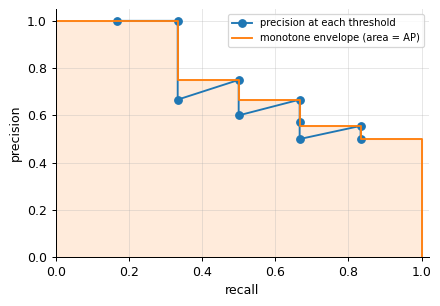

In [14]:
def average_precision(scores, is_tp, n_gt):
    # COCO-style AP: area under the monotone precision envelope, sampled at 101 recall points
    order = np.argsort(-np.asarray(scores), kind="stable")
    tp = np.asarray(is_tp, float)[order]
    ctp, cfp = np.cumsum(tp), np.cumsum(1 - tp)
    recall, precision = ctp / max(n_gt, 1), ctp / np.maximum(ctp + cfp, 1e-12)
    mrec, mpre = np.concatenate([[0.0], recall, [1.0]]), np.concatenate([[1.0], precision, [0.0]])
    envelope = np.flip(np.maximum.accumulate(np.flip(mpre)))
    r = np.linspace(0, 1, 101)
    return np.trapezoid(np.interp(r, mrec, envelope), r), recall, precision, mrec, envelope

# toy example: 10 predictions (sorted by score), 6 ground-truth objects
toy_scores = np.array([.95, .9, .85, .8, .7, .6, .5, .4, .3, .2])
toy_tp = np.array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0])
ap, rec, prec, mrec, env = average_precision(toy_scores, toy_tp, n_gt=6)
print(pd.DataFrame({"score": toy_scores, "TP": toy_tp, "precision": prec.round(2), "recall": rec.round(2)}).T.to_string(header=False))
print(f"\nAP = {ap:.3f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(rec, prec, "o-", label="precision at each threshold")
ax.step(mrec, env, where="post", c="C1", label="monotone envelope (area = AP)")
ax.fill_between(mrec, env, step="post", alpha=0.15, color="C1")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [15]:
def match(pred_boxes, pred_scores, gt_boxes, iou_thr=0.5):
    # greedy matching for one image and one class: is_tp flag for each prediction
    is_tp = np.zeros(len(pred_boxes))
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return is_tp
    ious, used = box_iou(pred_boxes, gt_boxes), np.zeros(len(gt_boxes), bool)
    for i in np.argsort(-pred_scores):
        j = np.argmax(np.where(used, -1.0, ious[i]))       # best still-unmatched ground truth
        if not used[j] and ious[i, j] >= iou_thr:
            is_tp[i], used[j] = 1, True
    return is_tp

def per_class_ap(preds, gts, n_classes, iou_thr=0.5):
    # preds: per image (boxes, scores, classes); gts: per image (boxes, classes)
    aps = []
    for c in range(n_classes):
        scores, flags, n_gt = [], [], 0
        for (pb, ps, pc), (gb, gc) in zip(preds, gts):
            mk = pc == c; n_gt += (gc == c).sum()
            scores.append(ps[mk]); flags.append(match(pb[mk], ps[mk], gb[gc == c], iou_thr))
        aps.append(average_precision(np.concatenate(scores), np.concatenate(flags), n_gt)[0])
    return np.array(aps)

## 8. Baseline: the COCO-pretrained model

The pretrained YOLO11n knows the 80 COCO classes. Two of our four classes are among them (**elephant** and **zebra**); **buffalo** and **rhino** are not. What does it predict on one validation image of each class?

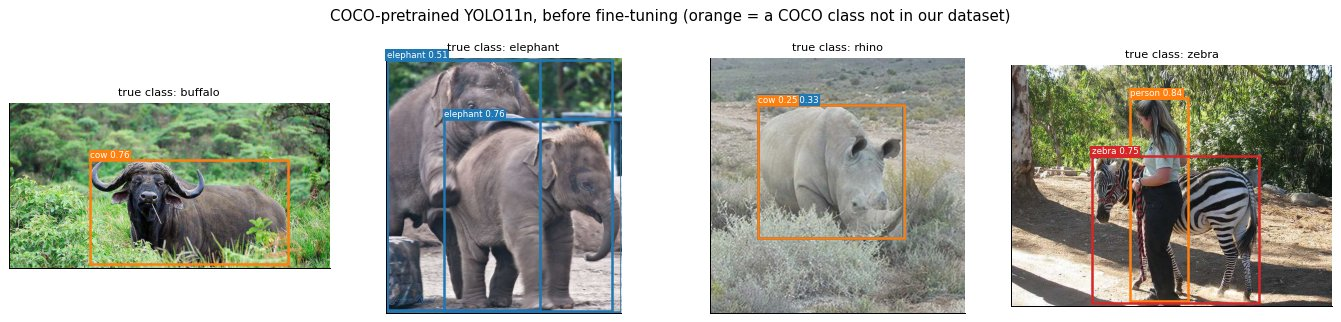

In [16]:
examples = [next(p for p in images("val") if p.name.startswith(f"{c + 1} (") and set(read_labels(p)[0]) == {c}) for c in range(4)]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, p in zip(axes, examples):
    r = coco.predict(str(p), conf=0.25, verbose=False)[0].cpu()
    names = [coco.names[int(c)] for c in r.boxes.cls]
    cols = [COLORS[CLASSES.index(n)] if n in CLASSES else "#ff7f0e" for n in names]
    draw(ax, load(p), r.boxes.xyxy.numpy(), [f"{n} {s:.2f}" for n, s in zip(names, r.boxes.conf)], cols,
         title=f"true class: {CLASSES[read_labels(p)[0][0]]}")
plt.suptitle("COCO-pretrained YOLO11n, before fine-tuning (orange = a COCO class not in our dataset)"); plt.tight_layout(); show_photos(fig)

Without any training on this dataset, the model already finds every animal and puts a sensible box around it. It detects the elephant and the zebra correctly, and even a person that our dataset does not label. It calls the buffalo a **cow** (the nearest COCO class) and is unsure about the rhino (*cow* 0.25, *elephant* 0.33). The backbone and the box regression already work; what is missing are the class names. Fine-tuning mostly has to teach the head four new classes, which is why a thousand images and a few minutes are enough.

## 9. Fine-tuning YOLO on the wildlife dataset

`YOLO("yolo11n.pt").train(data=...)` does transfer learning ([`notes_NN/03`](../notes_NN/03_cnn_transfer_multitask.ipynb), section 11): it keeps the pretrained backbone and neck, replaces the last classification layers of the head with ones for our $n_c = 4$ classes, and fine-tunes everything. The main arguments:

| Argument | Meaning | Here |
|---|---|---|
| `epochs` | passes over the training set | 20 on GPU, 8 on CPU |
| `imgsz` | images are letterboxed to `imgsz × imgsz` | 640 on GPU, 320 on CPU (4× fewer pixels) |
| `batch` | images per step | 16 |
| `optimizer`, `lr0` | `auto` picks SGD or AdamW and a learning rate from the dataset size | defaults |
| `freeze` | number of initial layers to freeze (feature extraction) | 0: fine-tune all |
| `patience` | early stopping on the validation fitness | default (100, i.e. off) |

**Augmentation is done for you**, and it is strong: random HSV colour jitter, horizontal flips, scale and translation, and **mosaic**, which tiles 4 training images into one. Mosaic shows objects at many scales and partially cut off, and packs more objects per batch. It is switched off for the last 10 epochs (`close_mosaic`) so the model finishes on images that look like the test images. Unlike classification, geometric augmentations must transform the **boxes** as well as the pixels, and Ultralytics does both.

After every epoch the model is evaluated on the validation split, and the weights with the best validation mAP50-95 (Ultralytics' *fitness*) are saved as `best.pt`. Everything is written to `runs/wildlife/`.

In [17]:
EPOCHS, IMGSZ = (20, 640) if DEVICE == 0 else (8, 320)
model = YOLO("yolo11n.pt")
Path("runs/wildlife/results.csv").unlink(missing_ok=True)     # the folder is reused (exist_ok) and this file is appended to
t0 = time.time()
model.train(data=str(DATA_YAML), epochs=EPOCHS, imgsz=IMGSZ, batch=16, device=DEVICE, workers=4, seed=0,
            project=str(Path("runs").resolve()), name="wildlife", exist_ok=True, plots=True)
RUN_DIR = Path(model.trainer.save_dir)
print(f"\ntraining took {(time.time() - t0) / 60:.1f} min; results in {RUN_DIR}")

Ultralytics 8.4.52 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32109MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0 ...
Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  

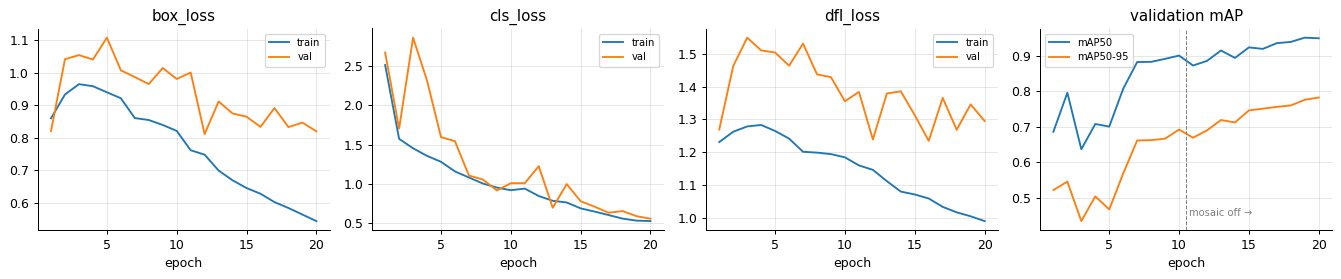

In [18]:
hist = pd.read_csv(RUN_DIR / "results.csv"); hist.columns = hist.columns.str.strip()
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, name in zip(axes, ["box_loss", "cls_loss", "dfl_loss"]):
    ax.plot(hist.epoch, hist[f"train/{name}"], label="train"); ax.plot(hist.epoch, hist[f"val/{name}"], label="val")
    ax.set_title(name); ax.set_xlabel("epoch"); ax.legend(fontsize=8)
axes[3].plot(hist.epoch, hist["metrics/mAP50(B)"], label="mAP50"); axes[3].plot(hist.epoch, hist["metrics/mAP50-95(B)"], label="mAP50-95")
axes[3].axvline(EPOCHS - 10 + 0.5, c="gray", lw=0.8, ls="--"); axes[3].text(EPOCHS - 10 + 0.7, 0.45, "mosaic off →", fontsize=8, c="gray")
axes[3].set_title("validation mAP"); axes[3].set_xlabel("epoch"); axes[3].legend(fontsize=8)
plt.tight_layout(); plt.show()

What to read in these curves:

- **The pretrained start.** After a single epoch the validation mAP50 is already ≈0.7: the features and the box regression transfer from COCO, and only the new 4-class output layer starts from scratch.
- **Train and validation losses are not directly comparable.** The training loss is measured on augmented mosaics, the validation loss on plain images. The validation box and DFL losses even rise during the first epochs, while the warm-up raises the learning rate and the new head is still random, and then come down.
- **Mosaic off.** In the last 10 epochs the training images look like the validation images, so the training loss falls faster and validation mAP keeps rising.
- **Not converged.** mAP50-95 is still going up at the last epoch, so more epochs would help (exercise 1). With `optimizer=auto`, Ultralytics chose AdamW with a small learning rate for this short run (see the log above).

## 10. Evaluation on the test set (and our own mAP)

The validation split was used to choose `best.pt`, so the honest estimate comes from the untouched **test** split.

In [19]:
best = YOLO(RUN_DIR / "weights" / "best.pt")
metrics = best.val(data=str(DATA_YAML), split="test", imgsz=IMGSZ, batch=16, device=DEVICE, verbose=False,
                   project=str(Path("runs").resolve()), name="wildlife_test", exist_ok=True)
test_table = pd.DataFrame({"AP50": metrics.box.ap50, "AP50-95": metrics.box.ap},
                          index=[CLASSES[i] for i in metrics.box.ap_class_index])
test_table.loc["mean (mAP)"] = test_table.mean()
print(test_table.round(3))

Ultralytics 8.4.52 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32109MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1823.3±1083.5 MB/s, size: 53.5 KB)
val: Scanning /home/datarocks3/trainings/ml-course/ML-course-labs/notes_NN/data/african-wildlife/labels/test.cache... 227 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 227/227 158.7Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 17.0it/s 0.9s

                   all        227        375       0.96      0.915      0.971       0.82
Speed: 0.5ms preprocess, 1.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/datarocks3/trainings/ml-course/ML-course-labs/notes_NN/runs/wildlife_test
             AP50  AP50-95
buffalo     0.971    0.871
elephant    0.978    0.784
rhino       0.973    0.878
zebra       0.962    0.747
mean

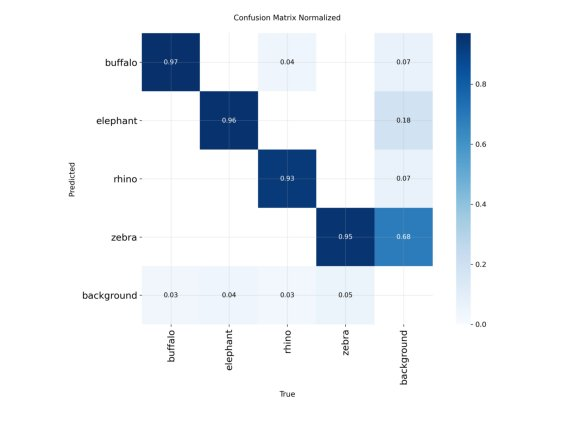

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.imshow(plt.imread(Path(metrics.save_dir) / "confusion_matrix_normalized.png")); ax.axis("off")
plt.tight_layout(); show_photos(fig)

The confusion matrix of a detector has an extra **background** row and column. The background *column* counts ground-truth objects that no prediction matched (missed animals, false negatives). The background *row* counts predictions that matched no object (false positives).

**Checking the library against our own code.** We run the model on the test images with the same settings as `val()` (confidence threshold 0.001, so that the whole PR curve is available; NMS IoU 0.7), then compute AP with the `match` and `average_precision` functions of section 7.

In [21]:
test_imgs = images("test")
preds, gts = [], []
for p in test_imgs:
    r = best.predict(str(p), conf=0.001, iou=0.7, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
    b = r.boxes.cpu().numpy()
    preds.append((b.xyxy, b.conf, b.cls.astype(int)))
    c, xywhn = read_labels(p); H, W = r.orig_shape
    gts.append((xywhn_to_xyxy(xywhn, W, H), c))

ours50 = per_class_ap(preds, gts, 4, 0.5)
ours5095 = np.mean([per_class_ap(preds, gts, 4, t) for t in np.arange(0.5, 0.96, 0.05)], axis=0)
cmp = pd.DataFrame({"AP50 (ours)": ours50, "AP50 (ultralytics)": metrics.box.ap50,
                    "AP50-95 (ours)": ours5095, "AP50-95 (ultralytics)": metrics.box.ap}, index=CLASSES)
cmp.loc["mean (mAP)"] = cmp.mean()
print(cmp.round(3))

            AP50 (ours)  AP50 (ultralytics)  AP50-95 (ours)  \
buffalo           0.976               0.971           0.869   
elephant          0.976               0.978           0.787   
rhino             0.955               0.973           0.861   
zebra             0.946               0.962           0.742   
mean (mAP)        0.963               0.971           0.815   

            AP50-95 (ultralytics)  
buffalo                     0.871  
elephant                    0.784  
rhino                       0.878  
zebra                       0.747  
mean (mAP)                  0.820  


The two implementations agree to about two decimals. The small differences come from preprocessing (`val()` batches images of similar aspect ratio together and pads them the same way, while `predict()` letterboxes each image on its own) and from details of the matching. That is also a reminder that reported mAP values are only comparable when they are computed with the same evaluation code.

## 11. Looking at the predictions

Metrics hide *what* goes wrong. Below, ground truth is dashed and predictions (score ≥ 0.4) are solid.

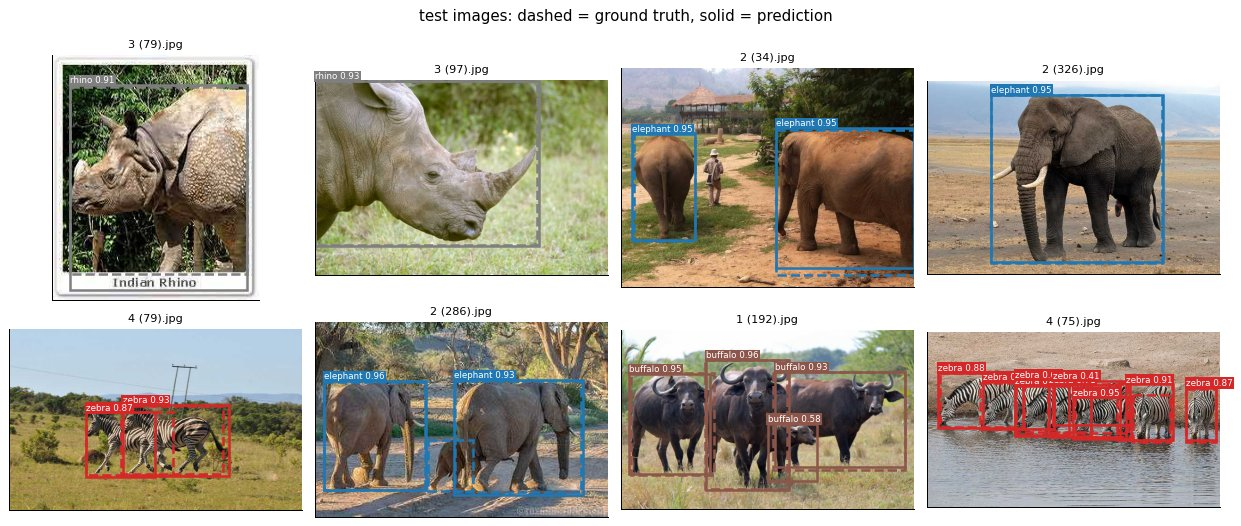

In [22]:
CONF = 0.4
def show_predictions(ax, idx, conf=CONF):
    p = test_imgs[idx]; pb, ps, pc = preds[idx]; m = ps >= conf
    draw_gt(ax, p, dashed=True, show_text=False)
    draw(ax, load(p), pb[m], [f"{CLASSES[c]} {s:.2f}" for c, s in zip(pc[m], ps[m])], [COLORS[c] for c in pc[m]], title=p.name)

fig, axes = plt.subplots(2, 4, figsize=(14, 6.2))
for ax, i in zip(axes.ravel(), rng.choice(len(test_imgs), 8, replace=False)):
    show_predictions(ax, i)
plt.suptitle("test images: dashed = ground truth, solid = prediction"); plt.tight_layout(); show_photos(fig)

**Choosing the confidence threshold.** An application must commit to one threshold. Counting true positives, false positives and missed objects on the test set (IoU ≥ 0.5, all classes) shows the trade-off that AP averages over:

In [23]:
def counts_at(conf, iou_thr=0.5):
    tp = fp = 0; n_gt = sum(len(g[1]) for g in gts); errors = []
    for i, ((pb, ps, pc), (gb, gc)) in enumerate(zip(preds, gts)):
        m = ps >= conf; img_tp = 0
        for c in range(4):
            mk = m & (pc == c)
            img_tp += match(pb[mk], ps[mk], gb[gc == c], iou_thr).sum()
        tp += img_tp; fp += m.sum() - img_tp
        if m.sum() - img_tp > 0 or img_tp < len(gc): errors.append(i)
    return dict(conf=conf, TP=int(tp), FP=int(fp), FN=int(n_gt - tp), precision=tp / max(tp + fp, 1), recall=tp / n_gt), errors

print(pd.DataFrame([counts_at(c)[0] for c in (0.05, 0.1, 0.25, 0.4, 0.6, 0.8)]).round(3).to_string(index=False))

 conf  TP  FP  FN  precision  recall
 0.05 362 207  13      0.636   0.965
 0.10 360 133  15      0.730   0.960
 0.25 356  54  19      0.868   0.949
 0.40 354  37  21      0.905   0.944
 0.60 343  14  32      0.961   0.915
 0.80 316   5  59      0.984   0.843


37 of 227 test images have at least one error at conf = 0.4


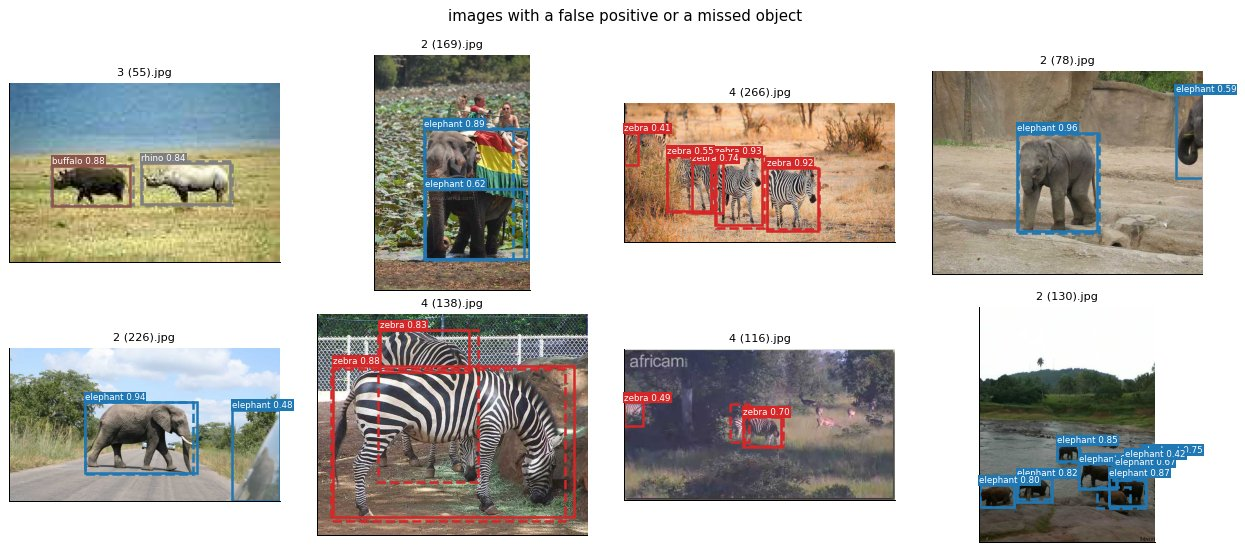

In [24]:
errors = counts_at(CONF)[1]
print(f"{len(errors)} of {len(test_imgs)} test images have at least one error at conf = {CONF}")
fig, axes = plt.subplots(2, 4, figsize=(14, 6.2))
for ax, i in zip(axes.ravel(), rng.choice(errors, min(8, len(errors)), replace=False)):
    show_predictions(ax, i)
plt.suptitle("images with a false positive or a missed object"); plt.tight_layout(); show_photos(fig)

Typical failure modes of a detector, most of them visible above:

- **Small, distant or blurry animals**: missed, or found with a low score. At `imgsz=320` (the CPU setting) there are even fewer pixels per animal.
- **Animals cut off by the image border** or hidden behind others: the model often detects a partial animal that the annotator did not label, which counts as a false positive.
- **Look-alike classes**: a black rhino called *buffalo*. Both are large, dark animals, and seen from the side at low resolution the horns are only a few pixels.
- **Crowds**: in a herd, overlapping animals of the same class are where NMS can wrongly merge two detections into one, or keep a duplicate box around two animals.
- **Annotation errors** (section 2): some "false positives" are correct detections of animals the annotator missed.

## 12. Speed and export to ONNX

Latency matters for real-time use. YOLO11n has 2.6 M parameters and needs about 6.5 GFLOPs per 640 × 640 image.

In [25]:
def latency_ms(model, img, device, n=30, **kw):
    for _ in range(3):
        model.predict(img, device=device, verbose=False, **kw)       # warm-up
    t0 = time.perf_counter()
    for _ in range(n):
        model.predict(img, device=device, verbose=False, **kw)
    return 1000 * (time.perf_counter() - t0) / n

img_bgr = np.ascontiguousarray(load(test_imgs[0])[:, :, ::-1])
for dev in ([0, "cpu"] if DEVICE == 0 else ["cpu"]):
    print(f"{'GPU' if dev == 0 else 'CPU'}: {latency_ms(best, img_bgr, dev, imgsz=IMGSZ):.1f} ms per image "
          f"(imgsz {IMGSZ}, including pre- and post-processing)")

GPU: 4.1 ms per image (imgsz 640, including pre- and post-processing)
CPU: 22.7 ms per image (imgsz 640, including pre- and post-processing)


To run the model outside Python and PyTorch (a C++ service, a phone, or a web browser with `onnxruntime-web`), export it to **ONNX**, a framework-independent graph format. Ultralytics can load the exported file again and run it with `onnxruntime`, so we can check that it gives the same boxes.

In [26]:
r_rect = best.predict(img_bgr, imgsz=IMGSZ, device="cpu", verbose=False)[0]
r_square = best.predict(img_bgr, imgsz=IMGSZ, device="cpu", verbose=False, rect=False)[0]
onnx_path = best.export(format="onnx", imgsz=IMGSZ, verbose=False)
r_onnx = YOLO(onnx_path, task="detect").predict(img_bgr, imgsz=IMGSZ, device="cpu", verbose=False)[0]
print(f"{Path(onnx_path).name}: {Path(onnx_path).stat().st_size / 1e6:.1f} MB")
for name, r in [("PyTorch, rectangular input", r_rect), ("PyTorch, square input", r_square), ("ONNX Runtime", r_onnx)]:
    print(f"{name:27s} boxes {r.boxes.xyxy.numpy().astype(float).round(1).tolist()}  scores {r.boxes.conf.numpy().astype(float).round(3).tolist()}")

Ultralytics 8.4.52 🚀 Python-3.12.3 torch-2.12.0+cu130 CPU (AMD Ryzen Threadripper 7970X 32-Cores)

PyTorch: starting from '/home/datarocks3/trainings/ml-course/ML-course-labs/notes_NN/runs/wildlife/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (5.2 MB)

ONNX: starting export with onnx 1.23.0 opset 20...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 0.8s, saved as '/home/datarocks3/trainings/ml-course/ML-course-labs/notes_NN/runs/wildlife/weights/best.onnx' (10.1 MB)

Export complete (0.8s)
Results saved to /home/datarocks3/trainings/ml-course/ML-course-labs/notes_NN/runs/wildlife/weights/best.onnx
Predict:         yolo predict task=detect model=/home/datarocks3/trainings/ml-course/ML-course-labs/notes_NN/runs/wildlife/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/datarocks3/trainings/ml-course/ML-course-labs/notes_NN/runs/wildlife/weights/best.onnx imgsz=640 data=data/african-wildlife/data.yaml 

The exported model gives exactly the same boxes as PyTorch **when both see the same input**. An ONNX model exported with a fixed shape always receives a $640\times640$ square: the image is resized and padded with grey (letterboxed). By default the PyTorch predictor pads only up to a multiple of 32 (e.g. $640\times480$), which is faster, so its boxes differ by a pixel or two. The `.onnx` file is also about twice the size of `best.pt`, because the checkpoint stores the weights as 16-bit floats and the export uses 32-bit.

## 13. A small application

Finally, a small web app around the trained model, built with **Gradio**. The user uploads a photo (or takes one with the webcam) and moves two sliders: the confidence threshold and the NMS IoU threshold of section 6. The app shows the detections and counts the animals of each class.

The next cell writes the app to `yolo_app.py` (it is also in the repository), so it can be run from a terminal:

```bash
cd deep_learning
python yolo_app.py --weights runs/wildlife/weights/best.pt           # open http://127.0.0.1:7860
python yolo_app.py --weights runs/wildlife/weights/best.pt --share   # plus a temporary public link
```

Nothing in it is specific to wildlife: it reads the class names from the model, so it works unchanged with a model trained on any other dataset.

In [27]:
%%writefile yolo_app.py
"""A small object-detection web app around a trained YOLO model (deep_learning/object_detection_yolo.ipynb).

Usage, from the deep_learning folder:
    python yolo_app.py --weights runs/wildlife/weights/best.pt
    python yolo_app.py --weights runs/wildlife/weights/best.pt --share    # temporary public link
"""
import argparse
from collections import Counter
from pathlib import Path

import gradio as gr
from ultralytics import YOLO


def make_detector(model):
    # wraps a YOLO model into detect(image, conf, iou) -> (annotated RGB image, [[class, count], ...])
    def detect(image, conf=0.4, iou=0.7):
        if image is None:
            return None, []
        result = model.predict(image, conf=conf, iou=iou, verbose=False)[0]   # PIL images are read as RGB
        annotated = result.plot()[:, :, ::-1]                                  # plot() draws in BGR; Gradio wants RGB
        counts = Counter(result.names[int(c)] for c in result.boxes.cls)
        return annotated, [[name, counts[name]] for name in result.names.values()]
    return detect


def build_demo(weights, examples=None):
    model = YOLO(weights)
    detect = make_detector(model)
    with gr.Blocks(title="Object detector") as demo:
        gr.Markdown(f"## Object detector\nDetects: {', '.join(model.names.values())}. "
                    "Upload a photo or use the webcam, then adjust the thresholds.")
        with gr.Row():
            with gr.Column():
                image = gr.Image(type="pil", label="Input image", sources=["upload", "webcam", "clipboard"])
                conf = gr.Slider(0.05, 0.95, value=0.4, step=0.05, label="Confidence threshold")
                iou = gr.Slider(0.1, 0.95, value=0.7, step=0.05, label="NMS IoU threshold")
                button = gr.Button("Detect", variant="primary")
            with gr.Column():
                output = gr.Image(label="Detections")
                counts = gr.Dataframe(headers=["class", "count"], label="Objects found")
        if examples:
            gr.Examples(examples, inputs=image)
        gr.on([button.click, image.change, conf.release, iou.release], detect, [image, conf, iou], [output, counts])
    return demo


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Object-detection web app")
    parser.add_argument("--weights", default="runs/wildlife/weights/best.pt")
    parser.add_argument("--examples", default="data/african-wildlife/images/test", help="folder with example images")
    parser.add_argument("--share", action="store_true", help="create a temporary public gradio.live link")
    args = parser.parse_args()
    folder = Path(args.examples)
    examples = sorted(str(p) for p in folder.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png"))[:8] if folder.is_dir() else None
    build_demo(args.weights, examples).launch(share=args.share)

Overwriting yolo_app.py


The detection function can be tested without the web interface:

   class  count
 buffalo      5
elephant      0
   rhino      0
   zebra      0


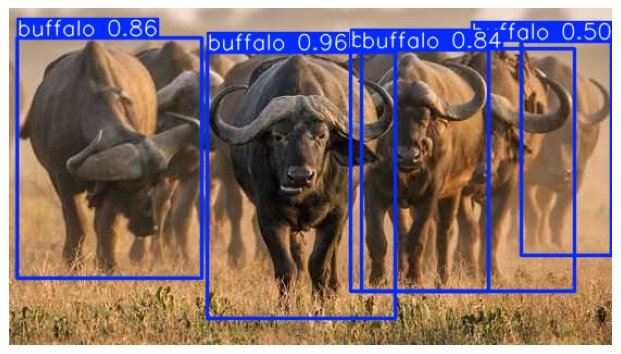

In [28]:
import importlib, yolo_app
importlib.reload(yolo_app)
detect = yolo_app.make_detector(YOLO(RUN_DIR / "weights" / "best.pt"))   # a fresh copy, as the app loads it
p = next(p for p in test_imgs if len(read_labels(p)[0]) >= 4)
annotated, rows = detect(Image.open(p), conf=0.4, iou=0.7)
print(pd.DataFrame(rows, columns=["class", "count"]).to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 5)); ax.imshow(annotated); ax.axis("off"); plt.tight_layout(); show_photos(fig)

And launched from the notebook. In Jupyter or VS Code the app is shown below the cell; in Colab, `share=True` also prints a public `*.gradio.live` link valid for a few days, which you can open on a phone and point its camera at a picture of an animal. Stop it with `demo.close()`.

In [ ]:
demo = yolo_app.build_demo(str(RUN_DIR / "weights" / "best.pt"), examples=[str(p) for p in test_imgs[:8]])
demo.launch(share=IN_COLAB)

## 14. Going further

1. **Train longer or bigger.** Increase `epochs` to 50–100, or use `yolo11s.pt` (9 M parameters). How much do mAP50 and mAP50-95 improve on the test set, and what does it cost in latency (section 12)?
2. **Feature extraction vs fine-tuning.** Train with `freeze=10` (the backbone is frozen) and compare with the fine-tuned model. Which classes suffer most, the COCO ones (elephant, zebra) or the new ones?
3. **Image size.** Compare `imgsz=320` and `640`. Which objects are lost at low resolution? (Look at the box-size scatter in section 2.)
4. **Your own dataset.** Take 50–100 photos of something you care about, label them in YOLO format with a tool such as [Label Studio](https://labelstud.io), [CVAT](https://www.cvat.ai) or [Roboflow](https://roboflow.com), write a `data.yaml` like the one in section 2, and train. The app of section 13 works unchanged. Many ready-made small datasets (vehicles, damage, PPE, packages…) are also listed at [docs.ultralytics.com/datasets/detect](https://docs.ultralytics.com/datasets/detect/).
5. **NMS-free.** Repeat the training with `YOLO("yolo26n.pt")`, whose head is trained with one-to-one assignment. Do the raw predictions still contain duplicates? Is it faster on CPU?
6. **Video.** `best.predict("video.mp4", stream=True)` yields one result per frame; `best.track(...)` also links detections across frames (multi-object tracking), which lets you count animals *passing* rather than per frame.

## Summary

- Detection outputs a **set** of (box, class, score) of unknown size. One-stage detectors like YOLO predict densely at every cell of several grids (strides 8, 16, 32 → 8400 candidates at 640 px) and then remove duplicates.
- **Boxes**: `xyxy` for geometry, `xywhn` in YOLO label files (normalised by the image size).
- **IoU** $= |A\cap B| / |A\cup B|$ is scale-invariant. IoU 0.5 corresponds to shifting a box by a third of its width. GIoU/CIoU give a gradient even without overlap and are used as box losses.
- **YOLO11 head**: anchor-free distances $(l,t,r,b)$ from each cell centre, each as a 16-bin distribution (DFL); independent sigmoid class scores.
- **Training**: the Task-Aligned Assigner picks the positives; the loss is $7.5\cdot(1-\text{CIoU}) + 0.5\cdot\text{BCE} + 1.5\cdot\text{DFL}$.
- **Inference**: confidence threshold, then per-class **NMS**.
- **Evaluation**: greedy matching at an IoU threshold → precision–recall curve → **AP**; mAP50 averages over classes, mAP50-95 also over IoU thresholds.
- **Practice**: fine-tuning a COCO-pretrained model on about a thousand labelled images takes minutes; export to ONNX to deploy anywhere; a few lines of Gradio turn it into an app.